In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from seaborn import color_palette
import h5py

from deep_lss.utils import emulator, abc
from msfm.utils import prior, files, parameters

from emcee import EnsembleSampler
from trianglechain import TriangleChain

print(tf.config.list_physical_devices())

23-05-24 07:11:51     utils.py INF   Loaded the config 
23-05-24 07:11:51   kernels.py INF   Setting the minimum value of the kernel function to 1e-42 for the mpmath library 
23-05-24 07:11:51    scales.py INF   Setting up healpy to run on 256 CPUs 
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
conf = files.load_config()

# load the summaries

In [ ]:
def load_preds(preds_file):
    with h5py.File(preds_file, "r") as f:
        # grid
        grid_preds = f["grid/preds"][:]
        grid_cosmos = f["grid/cosmos"][:]

        # fiducial
        fidu_preds = f["fiducial/preds"][:]
        
    return grid_preds, grid_cosmos, fidu_preds


In [3]:
# old

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-15_07-04-57_resnet_vanilla/preds.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    # grid
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    # fiducial
    fidu_preds = f["fiducial/preds"][:]

print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_b$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

<KeysViewHDF5 ['fiducial', 'grid']>
(2499, 16, 4)
(2499, 4)
(800, 4)


In [ ]:
# probably overfit

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-26-55_resnet_vanilla/preds_5000.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    # grid
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    # fiducial
    fidu_preds = f["fiducial/preds"][:]

# only select unique values of Om and s8
grid_cosmos = grid_cosmos[:,0,[2,4]]
    
print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

params = ["Om", "s8", "Aia", "n_Aia"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$A_ia$', r'$\eta_A$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

In [3]:
# clustering only, regular evaluation

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-18-42_resnet_vanilla/preds_5000.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    # grid
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    # fiducial
    fidu_preds = f["fiducial/preds"][:]
    
print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_b$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

<KeysViewHDF5 ['fiducial', 'grid']>
(2499, 16, 4)
(2499, 4)
(800, 4)


In [19]:
# lensing only, regular evaluation

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-18-42_resnet_vanilla/preds_10000.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    # grid
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    # fiducial
    fidu_preds = f["fiducial/preds"][:]

print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_b$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

<KeysViewHDF5 ['fiducial', 'grid']>
(2499, 16, 4)
(2499, 4)
(800, 4)


In [ ]:
# lensing only, regular evaluation, reduced parameters

preds_file = "/pscratch/sd/a/athomsen/run_files/v3/2023-05-24_05-18-42_resnet_vanilla/preds_10000.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    # grid
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    # fiducial
    fidu_preds = f["fiducial/preds"][:]

print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

params = ["Om", "s8"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$']
fiducial = {"Om": 0.26, "s8": 0.84}

### plot the summaries

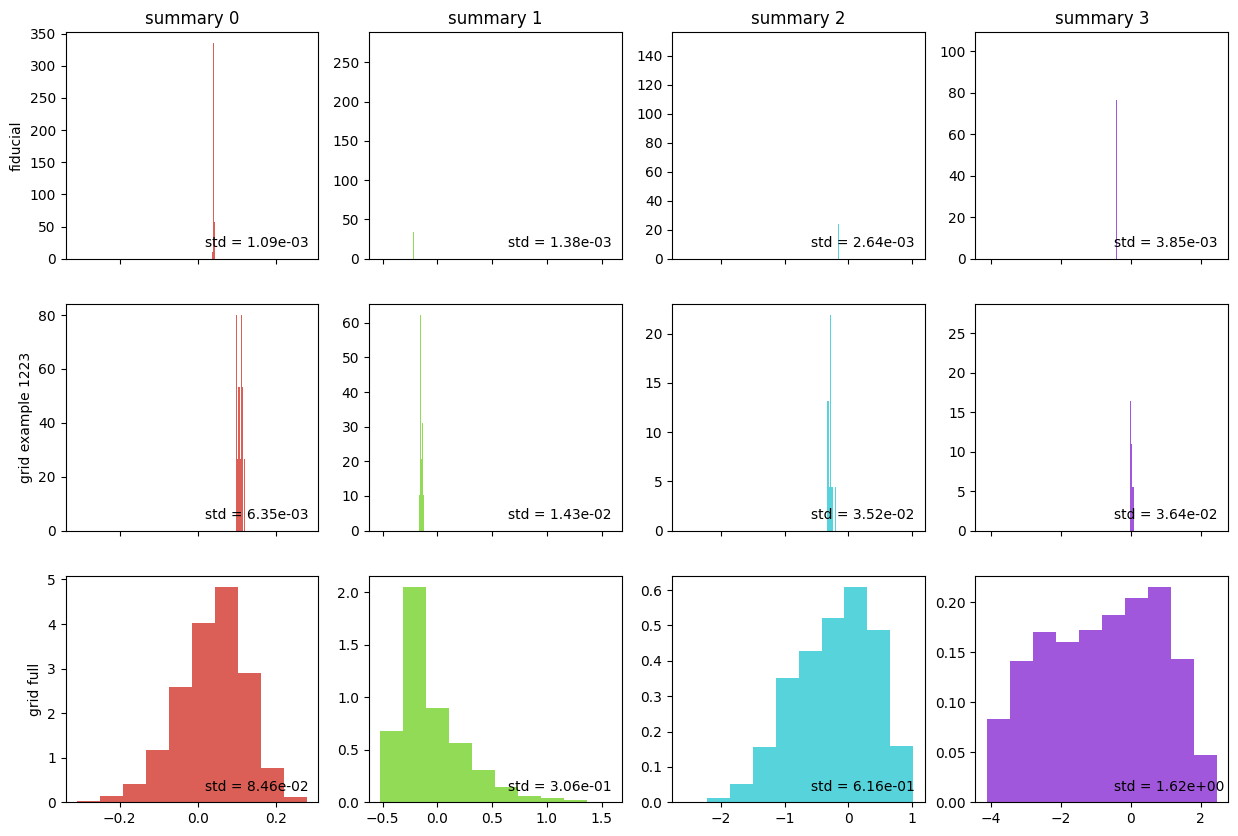

In [20]:
colors = color_palette("hls", n_params)

fig, ax = plt.subplots(nrows=3, ncols=n_params, figsize=(15,10), sharex="col")
# fig, ax = plt.subplots(nrows=3, ncols=n_params, figsize=(10,10))

ax[0,0].set(ylabel="fiducial")
for i in range(n_params):
    preds = fidu_preds[:,i]
    
    ax[0,i].hist(preds, density=True, color=colors[i])
    ax[0,i].set(title=f"summary {i}")
    ax[0,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[0,i].transAxes)

i_example = np.random.randint(grid_preds.shape[0])

ax[1,0].set(ylabel=f"grid example {i_example}")
for i in range(n_params):
    preds = grid_preds[i_example,:,i]
    
    ax[1,i].hist(preds, density=True, color=colors[i])
    ax[1,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[1,i].transAxes)

ax[2,0].set(ylabel="grid full")
for i in range(n_params):
    preds = grid_preds[:,:,i].flatten()
    
    ax[2,i].hist(preds, density=True, color=colors[i])
    ax[2,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[2,i].transAxes)


# Estimate the ABC posterior

### define the observation

In [21]:
# TODO make a distinction between validation and fiducial prediction
obs_pred = np.mean(fidu_preds, axis=0)

### estimate the Fisher matrix

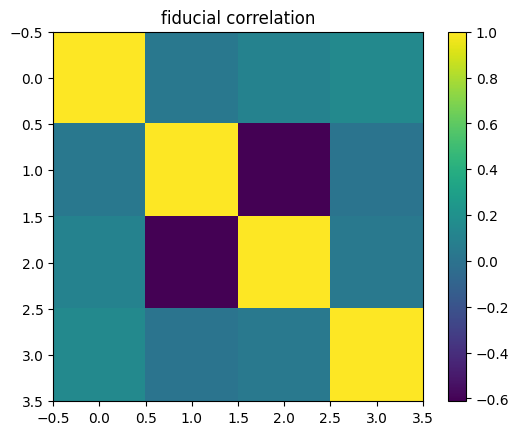

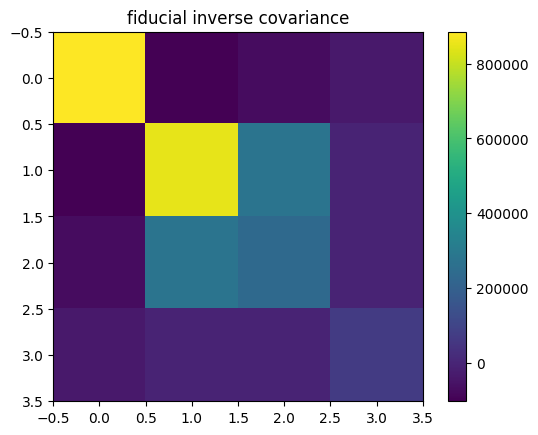

In [22]:
# get an approximation to the Fisher  matrix
fid_cov = np.cov(fidu_preds, rowvar=False)
fid_inv_cov = np.linalg.inv(fid_cov)

plt.imshow(np.corrcoef(fidu_preds, rowvar=False))
plt.colorbar()
plt.title("fiducial correlation")
plt.show()

plt.imshow(fid_inv_cov)
plt.colorbar()
plt.title("fiducial inverse covariance")
plt.show()

### ABC posterior

[Text(0.5, 1.0, 'ABC log posterior variance')]

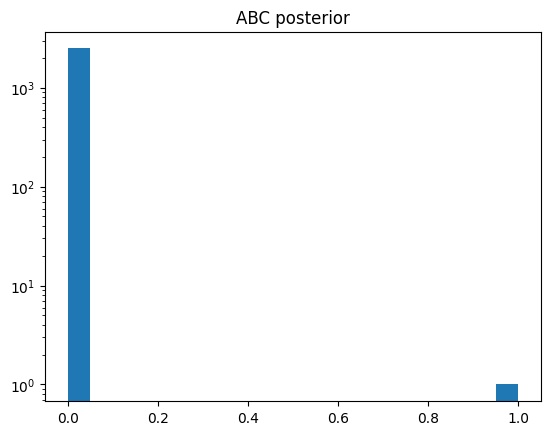

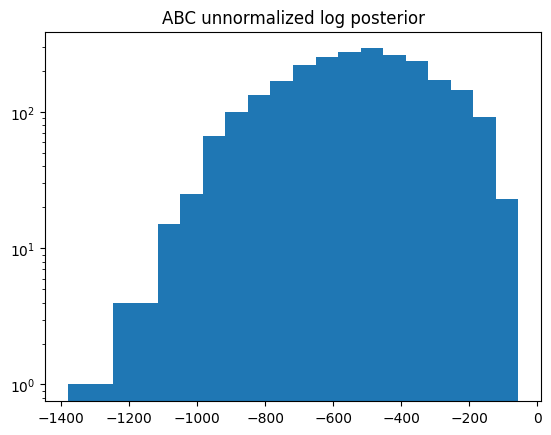

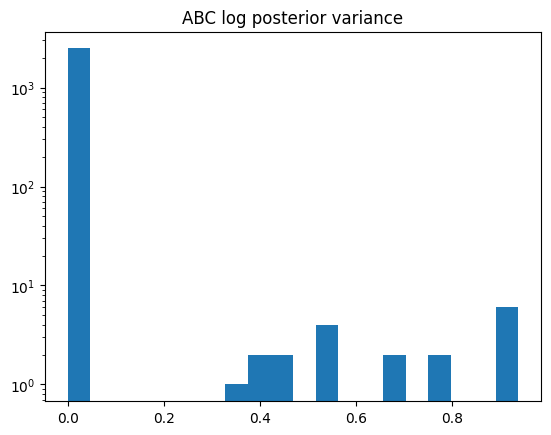

In [23]:
# kernel params
kernel = "sigmoid"
scale = 1.0

# Estimate the posterior and its uncertainties like in the paper
Y_init, abc_posterior = abc.estimate_grid_posterior(
    grid_preds=grid_preds, 
    fid_fisher=fid_inv_cov, 
    obs_pred=obs_pred, 
    scale=scale, 
    kernel=kernel
)

# check posterior
assert np.isclose(np.sum(abc_posterior), 1.0)

fig, ax = plt.subplots()
ax.hist(abc_posterior, log=True, bins=20)
ax.set(title="ABC posterior")

fig, ax = plt.subplots()
ax.hist(Y_init[:,0], log=True, bins=20)
ax.set(title="ABC unnormalized log posterior")

fig, ax = plt.subplots()
ax.hist(Y_init[:,1], log=True, bins=20)
ax.set(title="ABC log posterior variance")

In [24]:
Om = grid_cosmos[:,0]
s8 = grid_cosmos[:,1]

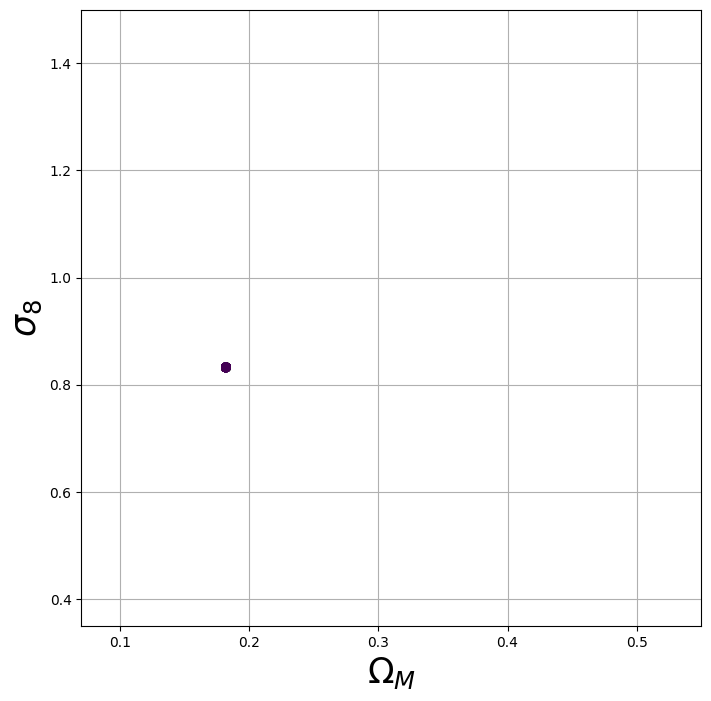

In [25]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(abc_posterior)), 100, p=abc_posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], abc_posterior[probable_indices],

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# Fit the emulator

In [26]:
X_init = grid_cosmos

# n_grid_points = 1000
# indices = np.random.choice(np.arange(X_init.shape[0]), n_grid_points, replace=False)

# X_init = X_init[indices]
# Y_init = Y_init[indices]

In [27]:
emu = emulator.VGP_Emu(
    X_init=X_init, 
    Y_init=Y_init, 
    kernel_type="squaredexponential", 
    normalize_X=True, 
    normalize_Y=True,
    Y_with_std=True, 
    ARD=True, 
)

╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ (4,)            │ float64 │ [1., 1., 1....   │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()              │ int32

In [28]:
emu.repeated_fit(n_steps=1000, n_restarts=1)

100%|████████████████████████████|   | 1000/1000 [01:43<00:00,  9.64it/s, loss_val=2.04e+4] fit the GP
23-05-24 07:21:06  emulator.py INF   Training run 0: loss = 20440.839420971464 
23-05-24 07:21:06  emulator.py INF   Training run 0 was best, setting those parameters 
╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════════════════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value                                    │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.13762                                  │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼─────────────

### plot the $\Omega_M - \sigma_8$ plane

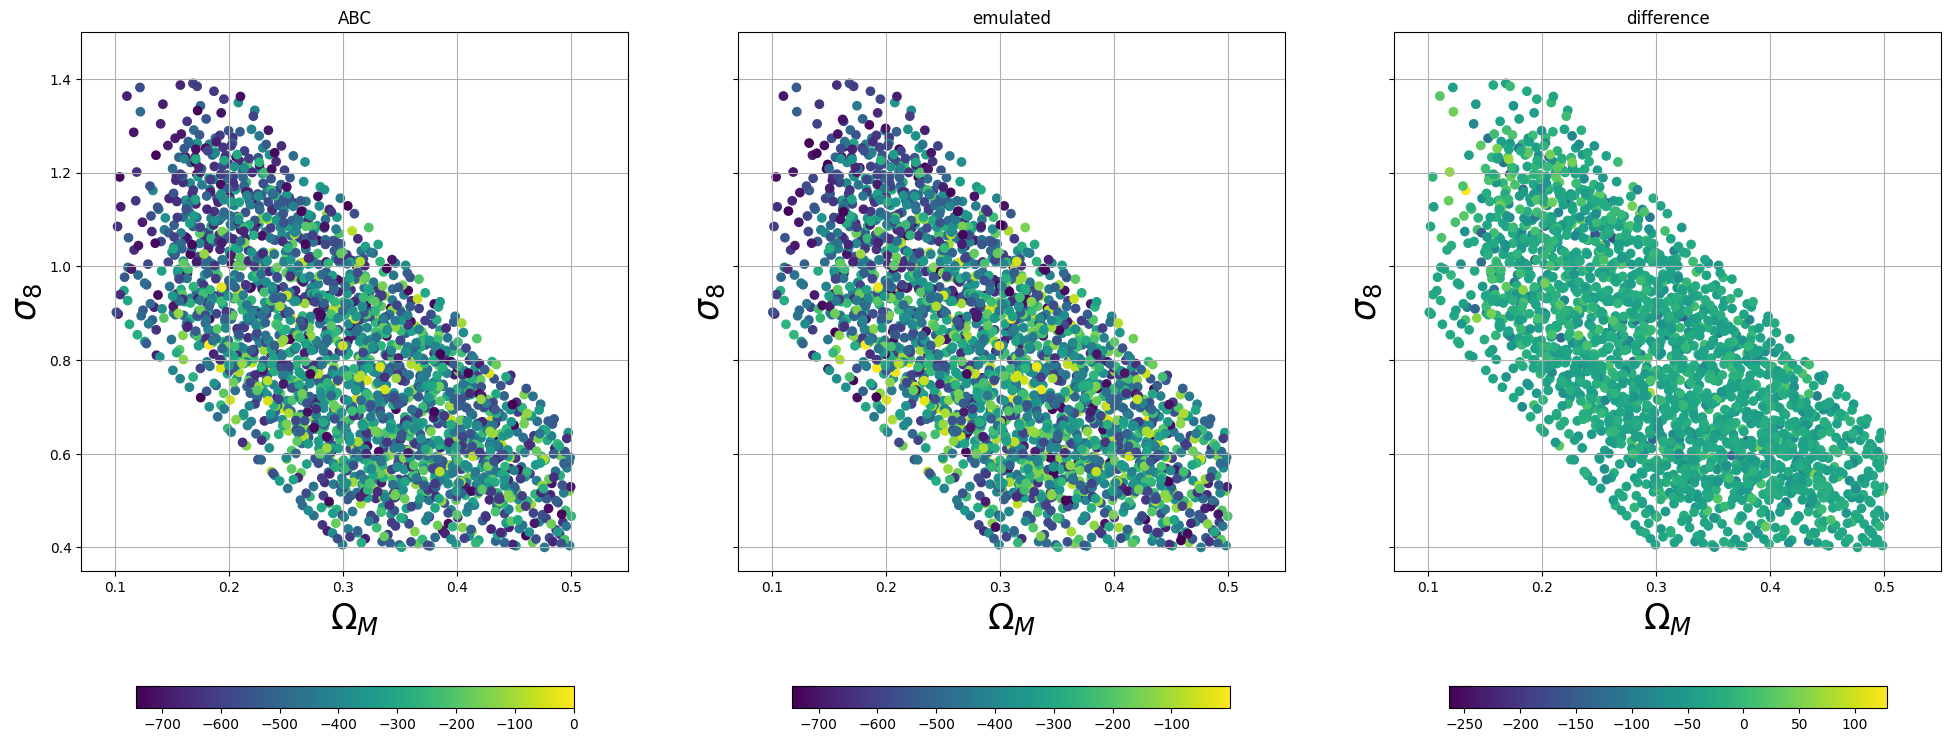

In [29]:
def normalize_Y(Y):
    normalized_prob = Y
    normalized_prob -= np.max(normalized_prob)
    normalized_prob = np.exp(normalized_prob)
    normalized_prob /= np.sum(normalized_prob) 
    
    return normalized_prob

fig, ax = plt.subplots(figsize=(24,10), ncols=3, sharex=True, sharey=True)

# original
original = np.log(normalize_Y(Y_init[:,0]))
im = ax[0].scatter(Om, s8, c=original)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
emulated = np.squeeze(np.log(normalize_Y(emu(X_init))))
im = ax[1].scatter(Om, s8, c=emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)

# difference
im = ax[2].scatter(Om, s8, c=original - emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[2].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="difference")
ax[2].set_xlabel("$\Omega_M$", fontsize=25)
ax[2].set_ylabel("$\sigma_8$", fontsize=25)
ax[2].grid(True)


# Run the MCMC

In [30]:
log_posterior = lambda X: prior.log_posterior(X, emu(X), params=params, conf=conf)

In [31]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
ndim = len(params)
p0 = np.random.normal(loc=parameters.get_fiducials(params), scale=1e-3, size=(nwalkers, ndim))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=params))) 

Initial values in prior:  True


In [ ]:
# sample burn in
sampler = EnsembleSampler(nwalkers, ndim, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()
# run the actual chain
sampler.run_mcmc(state, 1000, progress=True); 

 98%|█████████▊| 984/1000 [01:10<00:01, 13.85it/s]

In [ ]:
samples = sampler.get_chain(flat=True)

In [ ]:
tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})
tri.contour_cl(samples, names=params, label="GP ABC")
tri.scatter(
    fiducial,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
);

# OLD

### select correct cosmological parameters

In [5]:
for i in range(grid_cosmos.shape[1]):
    print(i, np.min(grid_cosmos[:,i]), "      ", np.max(grid_cosmos[:,i]))
    
Om = grid_cosmos[:,2]
s8 = grid_cosmos[:,4]

0 64.004395        81.98682
1 0.030029297        0.059970703
2 0.10039063        0.49990234
3 0.87009764        1.0699023
4 0.40024415        1.3973144
5 -1.9348828        -0.33381397
6 -2.9970703        2.999977


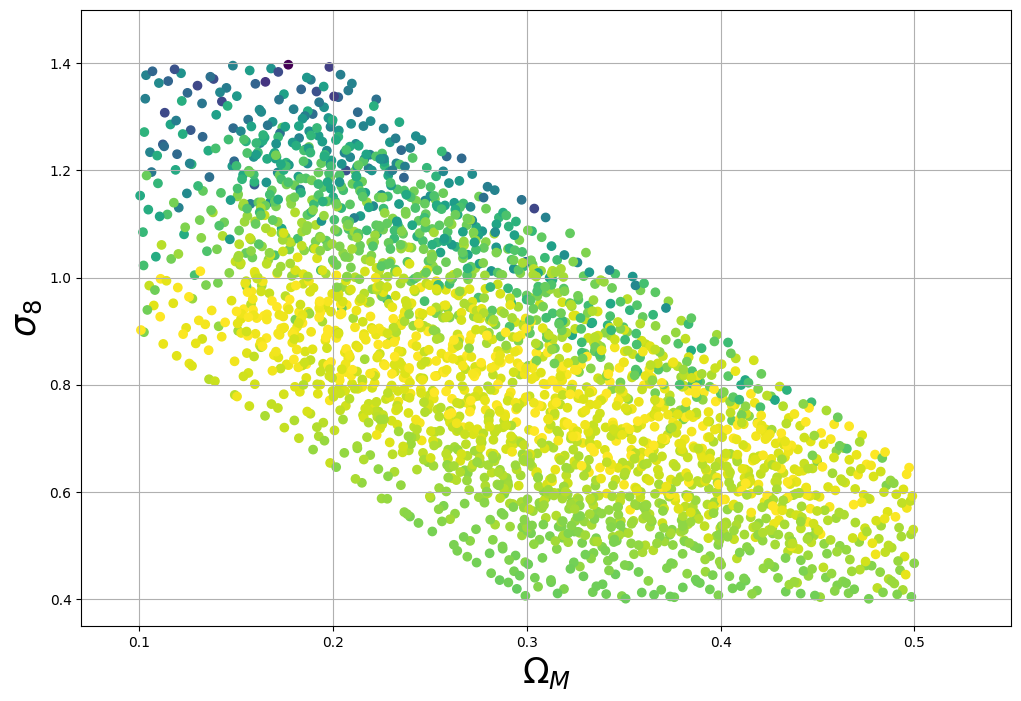

In [6]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(Om, s8, c=Y_init[:,0])
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

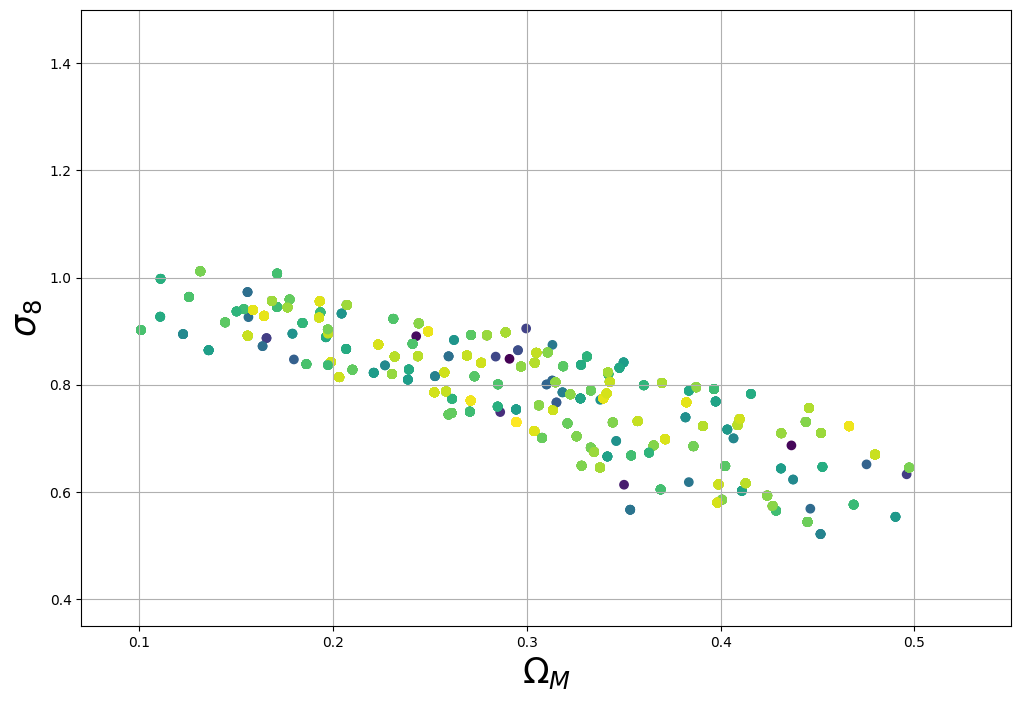

In [7]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(abc_posterior)), 5000, p=abc_posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], abc_posterior[probable_indices],

fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# Fit the GP emulator

In [6]:
X_init = np.stack([Om, s8], axis=-1)
X_init.shape

NameError: name 'Om' is not defined

In [54]:
X_init = grid_cosmos
print(X_init.shape)

(2499, 4)


In [87]:
emu = emulator.VGP_Emu(
    X_init=X_init[:1000], 
    Y_init=Y_init[:1000], 
    # X_init=X_init, 
    # Y_init=Y_init, 
    kernel_type="squaredexponential", 
    normalize_X=True, 
    normalize_Y=True,
    Y_with_std=True, 
    ARD=True, 
)

╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ (4,)            │ float64 │ [1., 1., 1....   │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()              │ int32

In [88]:
emu.repeated_fit(n_steps=1000, n_restarts=1)

100%|████████████████████████████|   | 1000/1000 [00:35<00:00, 27.92it/s, loss_val=4.34e+4] fit the GP
23-05-24 02:53:15  emulator.py INF   Training run 0: loss = 43385.92749414929 
23-05-24 02:53:15  emulator.py INF   Training run 0 was best, setting those parameters 
╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════════════════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value                                    │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0653                                   │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────

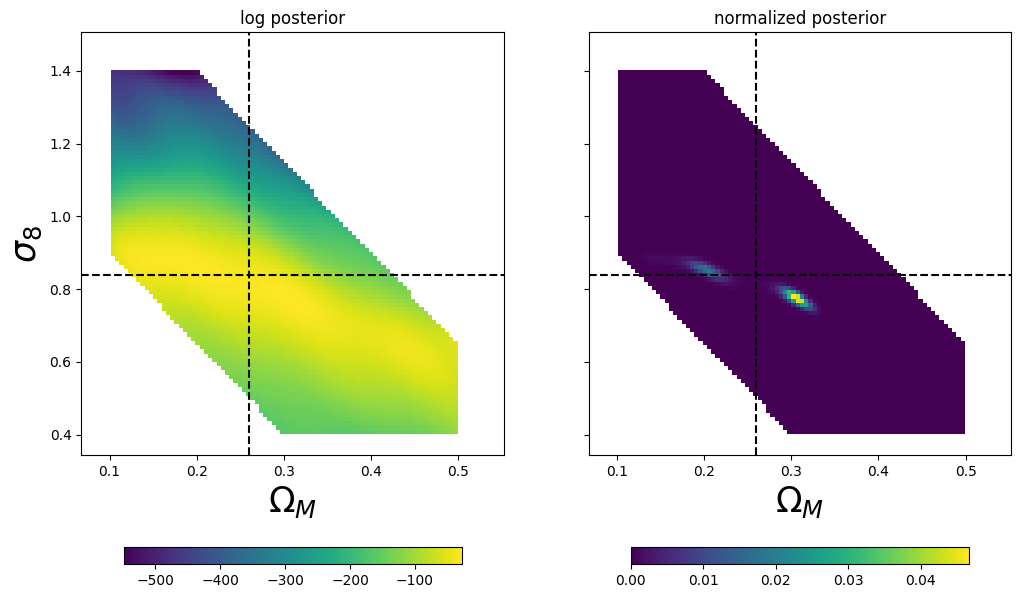

In [14]:
resolution = 100

Om_lin = np.linspace(0.07, 0.55, resolution)
s8_lin = np.linspace(0.35, 1.5, resolution)

# full coordinate arrays
Om_grid, s8_grid = np.meshgrid(Om_lin, s8_lin)

X = np.stack([Om_grid.ravel(), s8_grid.ravel()], axis=1)

log_posterior = emu(X)

# enforce the prior
in_prior = prior.in_grid_prior(X, params=["Om", "s8"])
log_posterior[~in_prior] = -np.inf

# reshape for the plot
log_posterior = log_posterior.reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(12,8), ncols=2, sharey=True)         

# log posterior
im = ax[0].pcolormesh(Om_lin, s8_lin, log_posterior)
fig.colorbar(im, orientation="horizontal", shrink=0.8)
ax[0].set(title="log posterior", xlabel="$\Omega_M$", ylabel="$\sigma_8$")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].set_box_aspect(1)
ax[0].axvline(0.26, color="k", linestyle="--")
ax[0].axhline(0.84, color="k", linestyle="--")

# normalized posterior
log_posterior -= np.max(log_posterior)
posterior = np.exp(log_posterior)
posterior /= np.sum(posterior)
posterior = np.ma.masked_array(posterior, ~in_prior.reshape(resolution, resolution))

im = ax[1].pcolormesh(Om_lin, s8_lin, posterior)
fig.colorbar(im, orientation="horizontal", shrink=0.8)
ax[1].set(title="normalized posterior")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_box_aspect(1)
ax[1].axvline(0.26, color="k", linestyle="--")
ax[1].axhline(0.84, color="k", linestyle="--")

# # S8
# S8 = s8*np.sqrt(Om/0.3)
# S8_lin = np.linspace(S8.min(), S8.max(), resolution)

# Om_mod = S8_lin**2/s8_lin**2 * 0.3
# s8_mod = S8_lin/np.sqrt(Om_lin/0.3)

# Om_grid, s8_grid = np.meshgrid(Om_lin, s8_lin)
# X = np.stack([Om_grid.ravel(), s8_grid.ravel()], axis=1)

# log_posterior = emu(X)

# im = ax[2].pcolormesh(Om_lin, s8_lin, log_posterior)
# fig.colorbar(im, orientation="horizontal", shrink=0.8)


# # full coordinate arrays
# Om_grid, s8_grid = np.meshgrid(Om_lin, s8_lin)


In [15]:
# emu.save_model("emulator")
# emu = emulator.VGP_Emu.load_model("emulator")

In [16]:
predictions = emu(X_init)

pred_post = predictions
pred_post -= np.max(pred_post)
pred_post = np.exp(pred_post)
pred_post /= np.sum(pred_post)

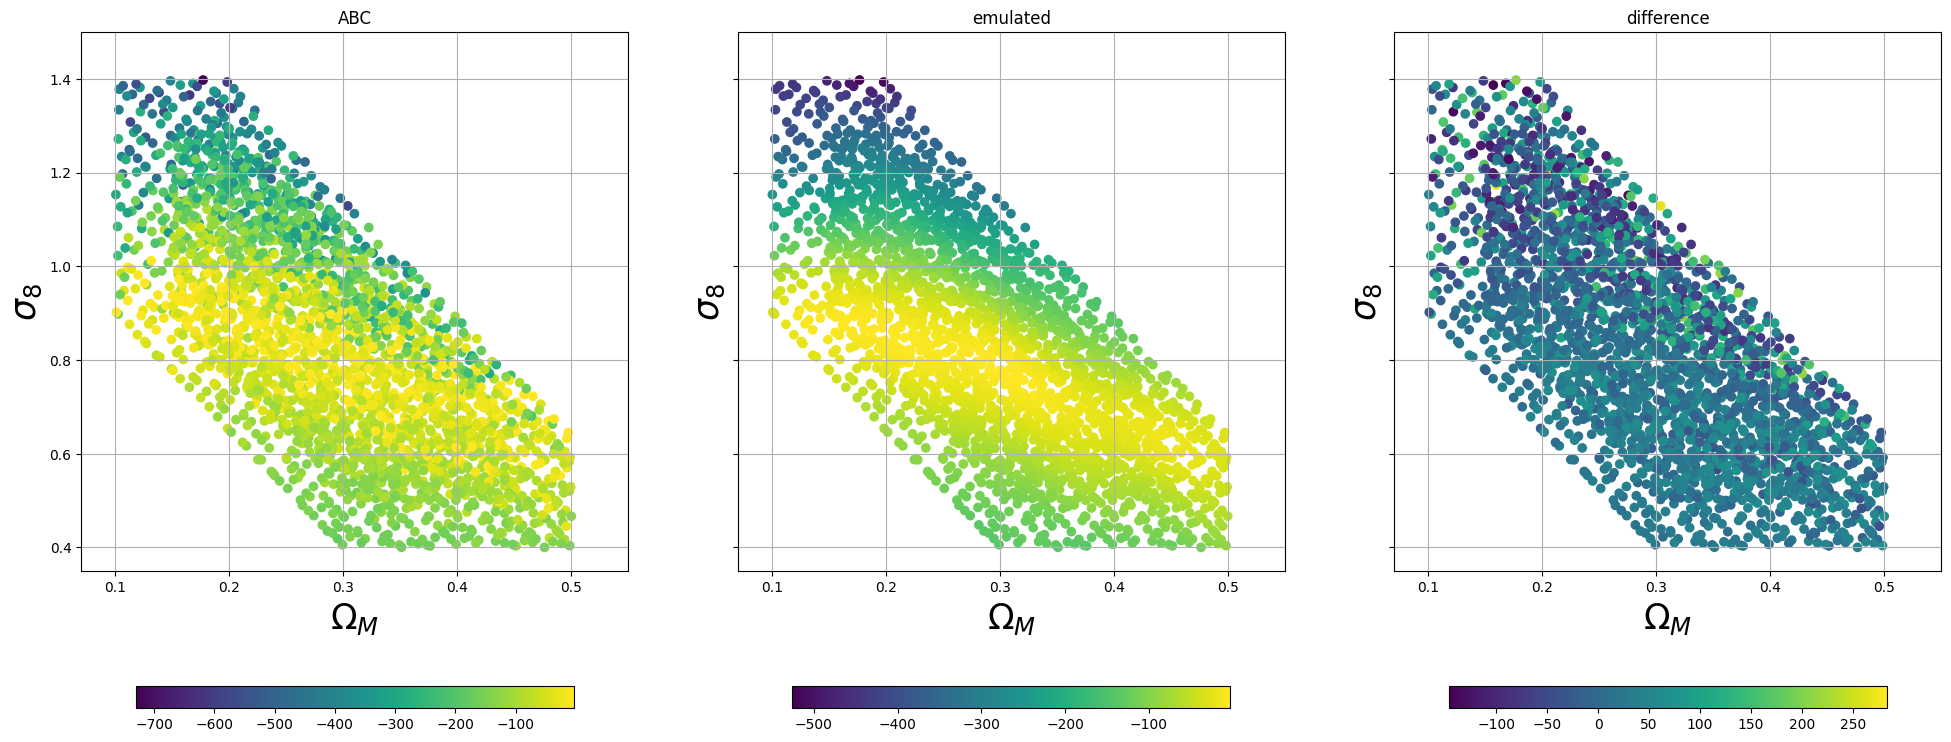

In [17]:
fig, ax = plt.subplots(figsize=(24,10), ncols=3, sharex=True, sharey=True)

# original
im = ax[0].scatter(Om, s8, c=np.log(abc_posterior))
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
im = ax[1].scatter(Om, s8, c=np.log(pred_post))
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)

# difference
im = ax[2].scatter(Om, s8, c=np.squeeze(np.log(pred_post)) - np.squeeze(np.log(abc_posterior)))
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[2].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="difference")
ax[2].set_xlabel("$\Omega_M$", fontsize=25)
ax[2].set_ylabel("$\sigma_8$", fontsize=25)
ax[2].grid(True)
